In [2]:
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [3]:
file_path = "heart_failure_clinical_records_dataset.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "andrewmvd/heart-failure-clinical-data",
    file_path
)

print("Dataset loaded successfully!")
print("\nFirst 5 records:")
display(df.head())

/tmp/ipykernel_1028/2996261506.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 12.0k/12.0k [00:00<00:00, 9.68MB/s]

Dataset loaded successfully!

First 5 records:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 299
Number of columns: 13


In [5]:
print("\nData types:")
print(df.dtypes)



Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [6]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [7]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5

In [8]:
# adding missing values

columns_to_make_missing = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "smoking"
]

# Introduce 5% missing values into each selected column
for col in columns_to_make_missing:
    missing_indices = np.random.choice(
        df.index,
        size=int(0.05 * len(df)),
        replace=False
    )

    df.loc[missing_indices, col] = np.nan

# Display missing values
print("Missing values created in the dataset:")
print(df.isnull().sum())

Missing values created in the dataset:
age                         14
anaemia                      0
creatinine_phosphokinase     0
diabetes                     0
ejection_fraction           14
high_blood_pressure          0
platelets                    0
serum_creatinine            14
serum_sodium                14
sex                          0
smoking                     14
time                         0
DEATH_EVENT                  0
dtype: int64


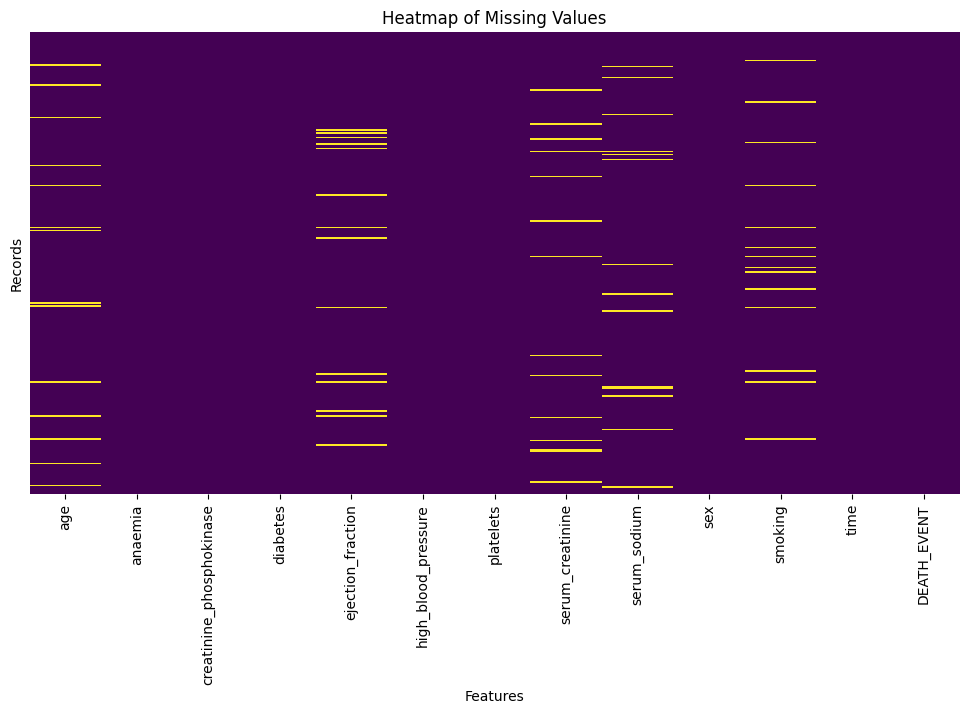

In [9]:
# visualizing missing values

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Heatmap of Missing Values")
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

In [10]:
# plotting

# Numerical columns
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


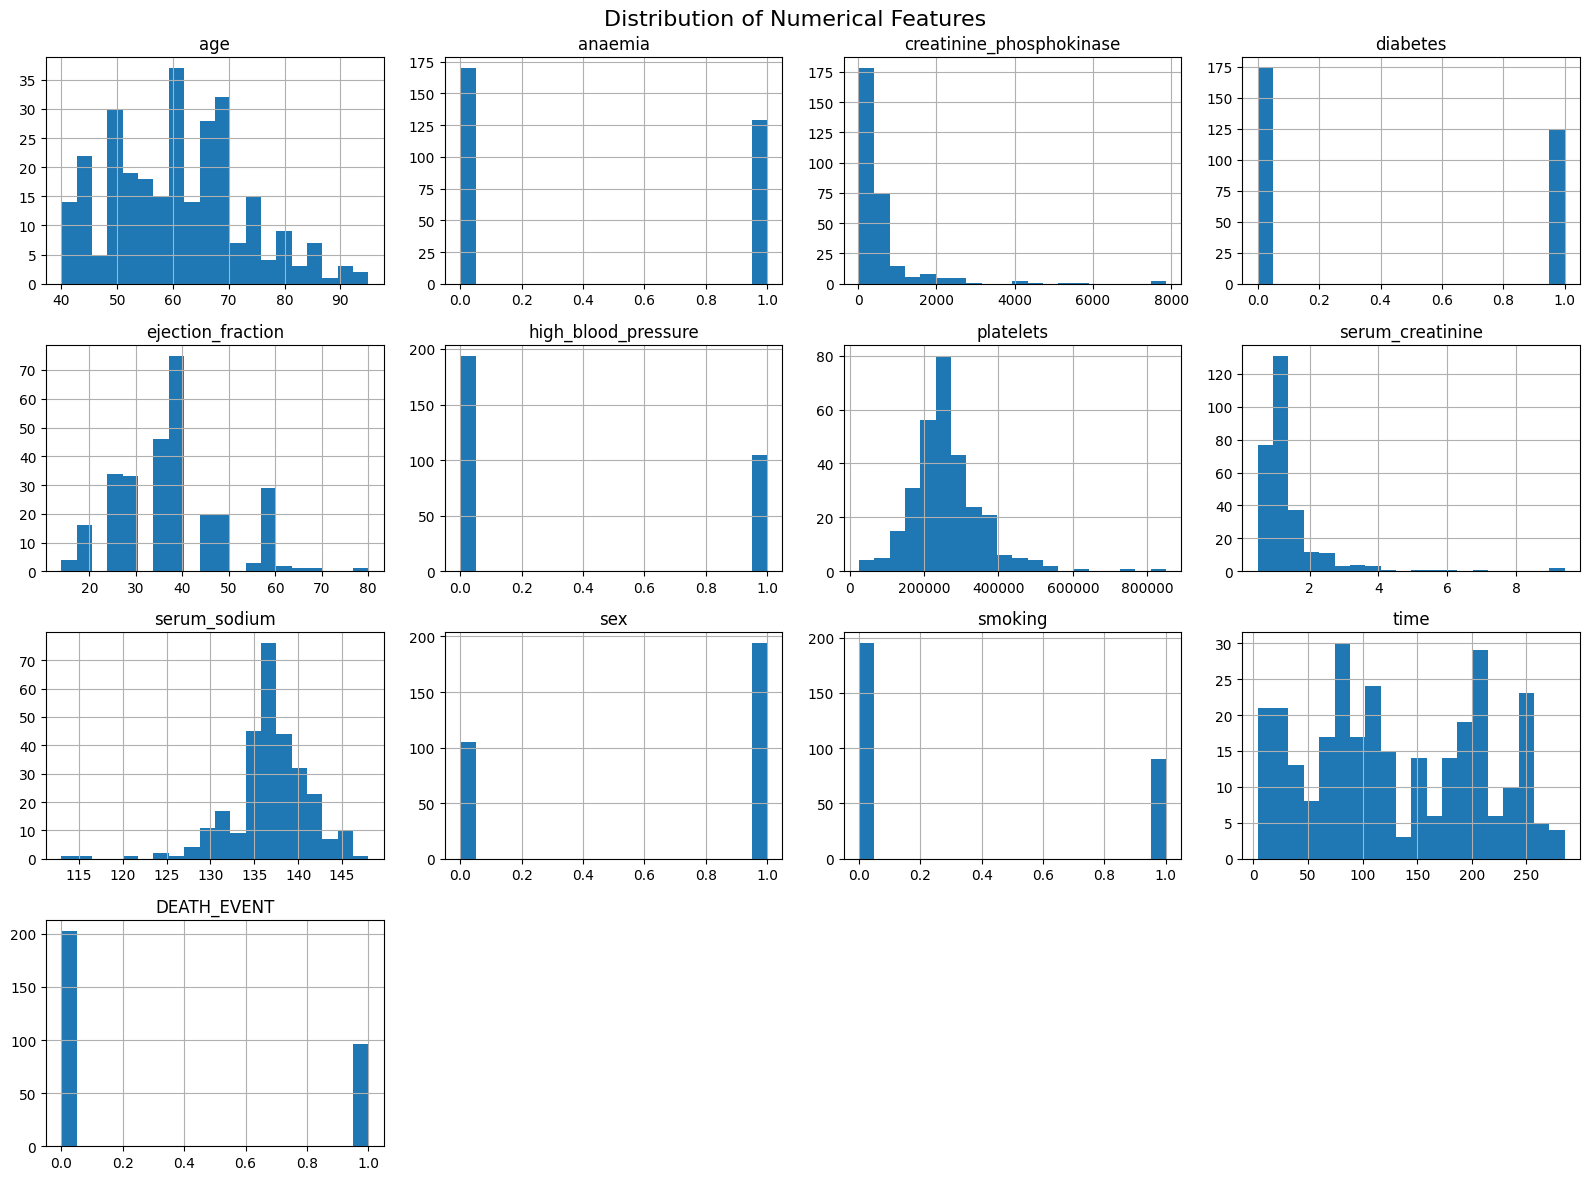

In [11]:
# Plot histograms for numerical features

df[numerical_columns].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

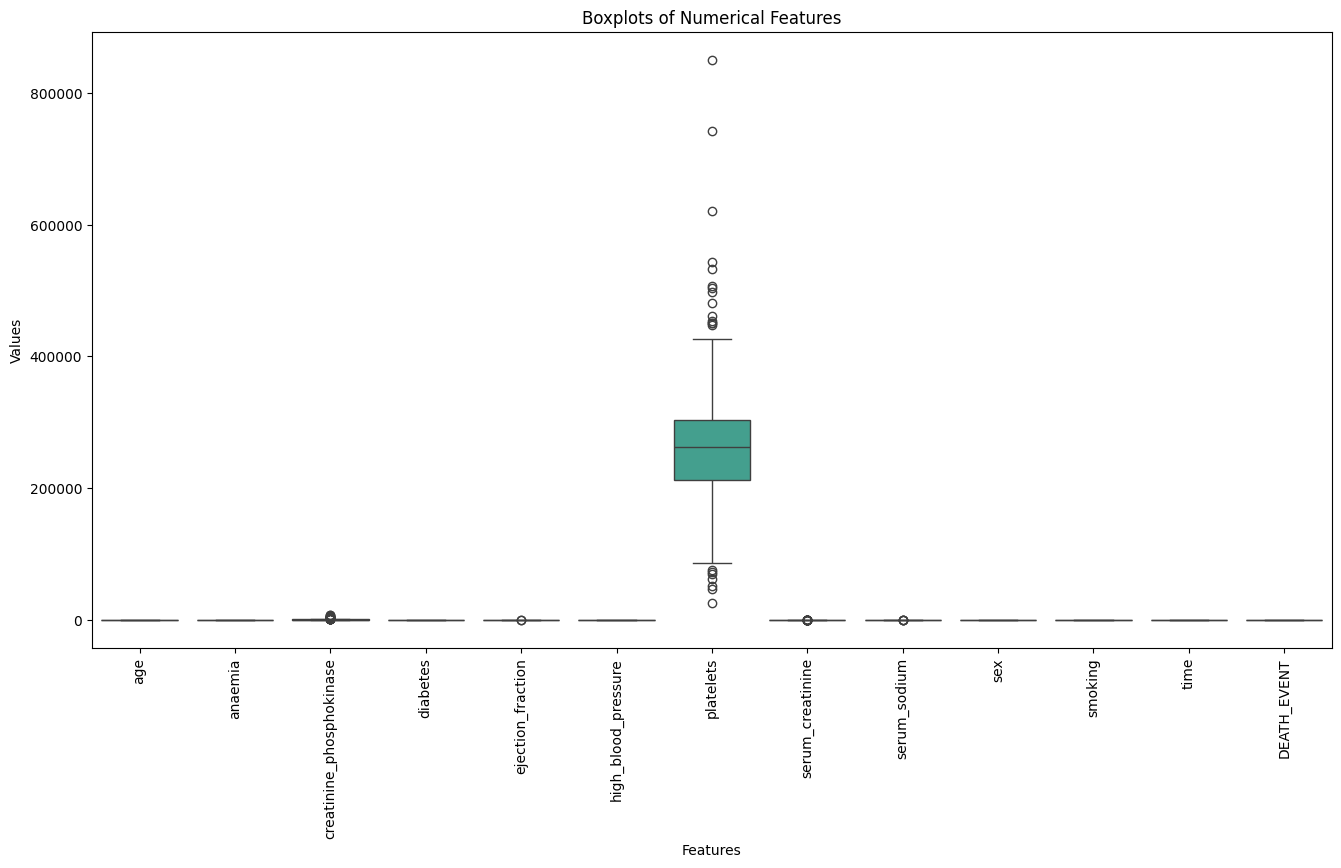

In [12]:
# Plot boxplots for numerical features

plt.figure(figsize=(16, 8))

sns.boxplot(data=df[numerical_columns])

plt.title("Boxplots of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.xticks(rotation=90)

plt.show()

In [13]:
# impute missing values

print("Missing values before imputation:")
print(df.isnull().sum())

Missing values before imputation:
age                         14
anaemia                      0
creatinine_phosphokinase     0
diabetes                     0
ejection_fraction           14
high_blood_pressure          0
platelets                    0
serum_creatinine            14
serum_sodium                14
sex                          0
smoking                     14
time                         0
DEATH_EVENT                  0
dtype: int64


In [14]:
# Impute numerical columns using median

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Identify categorical columns
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

# Impute categorical columns using mode

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)

Categorical columns:
[]
Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total missing values: 0


In [15]:
# removing outliers

rows_before = len(df)

print("Rows before outlier removal:", rows_before)

Rows before outlier removal: 299


In [16]:
# Remove outliers using IQR method

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

rows_after = len(df)

print("Rows after outlier removal:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows after outlier removal: 220
Rows removed: 79


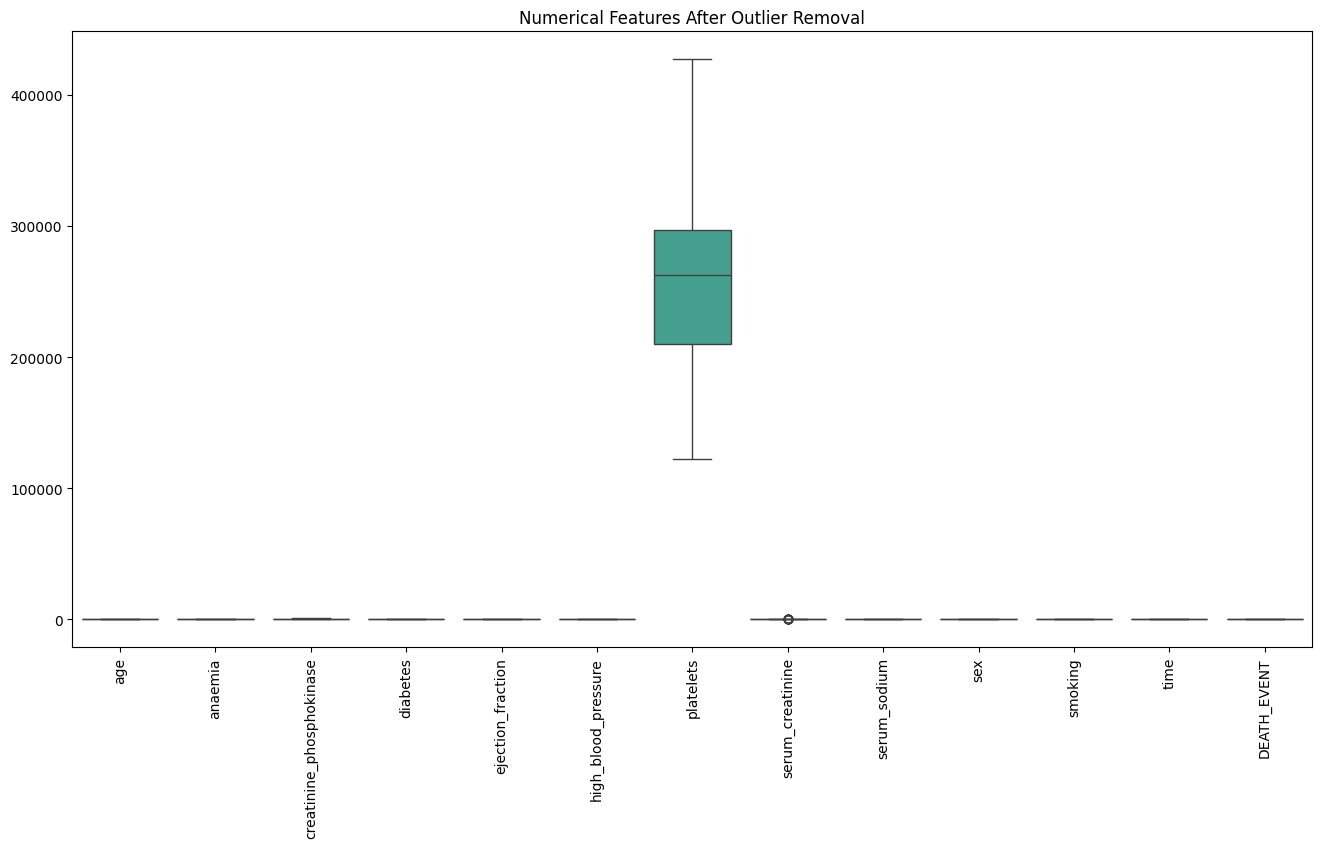

In [17]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df[numerical_columns])

plt.title("Numerical Features After Outlier Removal")
plt.xticks(rotation=90)

plt.show()

In [18]:
# Correct Inconsistencies

# Introduce some invalid negative age values

np.random.seed(42)

invalid_age_indices = np.random.choice(
    df.index,
    size=5,
    replace=False
)

df.loc[invalid_age_indices, "age"] = -25

print("Invalid age values introduced:")
print(df.loc[invalid_age_indices, ["age"]])

Invalid age values introduced:
      age
184 -25.0
204 -25.0
132 -25.0
248 -25.0
23  -25.0


In [19]:
# Check for invalid negative age values

invalid_age = df[df["age"] < 0]

print("Number of invalid negative ages:", len(invalid_age))

print("\nInvalid age records:")
display(invalid_age[["age"]])

Number of invalid negative ages: 5

Invalid age records:


,age
23,-25.0
132,-25.0
184,-25.0
204,-25.0
248,-25.0


In [20]:
# fixing -ve age values

# Calculate median of valid ages
valid_age_median = df.loc[df["age"] >= 0, "age"].median()

print("Median valid age:", valid_age_median)

# Replace negative ages with the median
df.loc[df["age"] < 0, "age"] = valid_age_median

Median valid age: 60.0


In [21]:
# Check for any negative age values

remaining_invalid_age = df[df["age"] < 0]

print("Negative ages remaining:", len(remaining_invalid_age))

if len(remaining_invalid_age) == 0:
    print("All invalid negative age values have been corrected.")
else:
    print("Invalid negative age values still remain.")

Negative ages remaining: 0
All invalid negative age values have been corrected.


In [22]:
# displaying corrected ages

print("Corrected age values:")
display(df.loc[invalid_age_indices, ["age"]])

Corrected age values:


,age
184,60.0
204,60.0
132,60.0
248,60.0
23,60.0


In [23]:
# feature engineering

# creating age_group feature

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

print(df["age_group"].value_counts())

display(
    df[["age", "age_group"]].head(10)
)

age_group
>60      129
40-60     91
<40        0
Name: count, dtype: int64


,age,age_group
0,75.0,>60
2,65.0,>60
3,50.0,40-60
5,90.0,>60
6,75.0,>60
8,65.0,>60
11,62.0,>60
12,45.0,40-60
13,50.0,40-60
14,49.0,40-60


In [24]:
# creating risk_score feature

df["risk_score_raw"] = (
    df["ejection_fraction"] *
    df["serum_creatinine"]
)

In [25]:
# normalize it to 0–1

risk_min = df["risk_score_raw"].min()
risk_max = df["risk_score_raw"].max()

df["risk_score"] = (
    (df["risk_score_raw"] - risk_min) /
    (risk_max - risk_min)
)

In [26]:
# removing the temporary column

df.drop(
    columns=["risk_score_raw"],
    inplace=True
)

# checking

display(
    df[
        [
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head(10)
)

,ejection_fraction,serum_creatinine,risk_score
0,20.0,1.9,0.269939
2,20.0,1.3,0.122699
3,20.0,1.9,0.269939
5,40.0,2.1,0.834356
6,15.0,1.2,0.024540
8,65.0,1.5,1.000000
11,25.0,0.9,0.079755
12,30.0,1.1,0.208589
13,38.0,1.1,0.316564
14,30.0,1.0,0.171779


In [27]:
# Encode Categorical Variables

# Checking categorical columns

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['age_group']


In [28]:
# applying one-hot encoding age_group

df = pd.get_dummies(
    df,
    columns=["age_group"],
    drop_first=True
)

print("Dataset after encoding:")
display(df.head())

Dataset after encoding:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,75.0,0,582,0,20.0,1,265000.0,1.9,130.0,1,0.0,4,1,0.269939,False,True
2,65.0,0,146,0,20.0,0,162000.0,1.3,129.0,1,1.0,7,1,0.122699,False,True
3,50.0,1,111,0,20.0,0,210000.0,1.9,137.0,1,0.0,7,1,0.269939,True,False
5,90.0,1,47,0,40.0,1,204000.0,2.1,132.0,1,1.0,8,1,0.834356,False,True
6,75.0,1,246,0,15.0,0,127000.0,1.2,137.0,1,0.0,10,1,0.024540,False,True


In [29]:
# normalizing numerical features

from sklearn.preprocessing import MinMaxScaler

# numerical features that should be normalized
columns_to_scale = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

print("Features to normalize:")
print(columns_to_scale)

Features to normalize:
['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']


In [30]:
# Calculate statistics before normalization

stats_before = df[columns_to_scale].agg(
    ["mean", "median", "std"]
).T

print("Statistics BEFORE normalization:")
display(stats_before)

Statistics BEFORE normalization:


,mean,median,std
age,60.837882,60.0,11.681746
creatinine_phosphokinase,333.386364,211.5,278.817547
ejection_fraction,38.100000,38.0,11.223711
platelets,255940.011682,262500.0,67310.392577
serum_creatinine,1.126136,1.1,0.321322
serum_sodium,137.140909,137.0,3.455280
time,132.704545,120.0,76.477764


In [31]:
# Creating scaler
scaler = MinMaxScaler()

# Normaling numerical features
df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

In [32]:
print("Normalized numerical features:")
display(df[columns_to_scale].head())

Normalized numerical features:


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
0,0.636364,0.470990,0.1,0.468852,0.866667,0.117647,0.000000
2,0.454545,0.098976,0.1,0.131148,0.466667,0.058824,0.010676
3,0.181818,0.069113,0.1,0.288525,0.866667,0.529412,0.010676
5,0.909091,0.014505,0.5,0.268852,1.000000,0.235294,0.014235
6,0.636364,0.184300,0.0,0.016393,0.400000,0.529412,0.021352


In [34]:
# verifying

print("Minimum values:")
print(df[columns_to_scale].min())

print("\nMaximum values:")
print(df[columns_to_scale].max())

Minimum values:
age                         0.0
creatinine_phosphokinase    0.0
ejection_fraction           0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
time                        0.0
dtype: float64

Maximum values:
age                         1.0
creatinine_phosphokinase    1.0
ejection_fraction           1.0
platelets                   1.0
serum_creatinine            1.0
serum_sodium                1.0
time                        1.0
dtype: float64


In [35]:
# Statistics AFTER cleaning and normalization

stats_after = df[columns_to_scale].agg(
    ["mean", "median", "std"]
).T

print("Statistics AFTER cleaning and normalization:")
display(stats_after)

Statistics AFTER cleaning and normalization:


,mean,median,std
age,0.378871,0.363636,0.212395
creatinine_phosphokinase,0.258862,0.154863,0.237899
ejection_fraction,0.462000,0.460000,0.224474
platelets,0.439148,0.460656,0.220690
serum_creatinine,0.350758,0.333333,0.214214
serum_sodium,0.537701,0.529412,0.203252
time,0.458023,0.412811,0.272163


In [36]:
# Combine before and after statistics

comparison = pd.concat(
    [
        stats_before.add_suffix("_before"),
        stats_after.add_suffix("_after")
    ],
    axis=1
)

display(comparison)

,mean_before,median_before,std_before,mean_after,median_after,std_after
age,60.837882,60.0,11.681746,0.378871,0.363636,0.212395
creatinine_phosphokinase,333.386364,211.5,278.817547,0.258862,0.154863,0.237899
ejection_fraction,38.100000,38.0,11.223711,0.462000,0.460000,0.224474
platelets,255940.011682,262500.0,67310.392577,0.439148,0.460656,0.220690
serum_creatinine,1.126136,1.1,0.321322,0.350758,0.333333,0.214214
serum_sodium,137.140909,137.0,3.455280,0.537701,0.529412,0.203252
time,132.704545,120.0,76.477764,0.458023,0.412811,0.272163


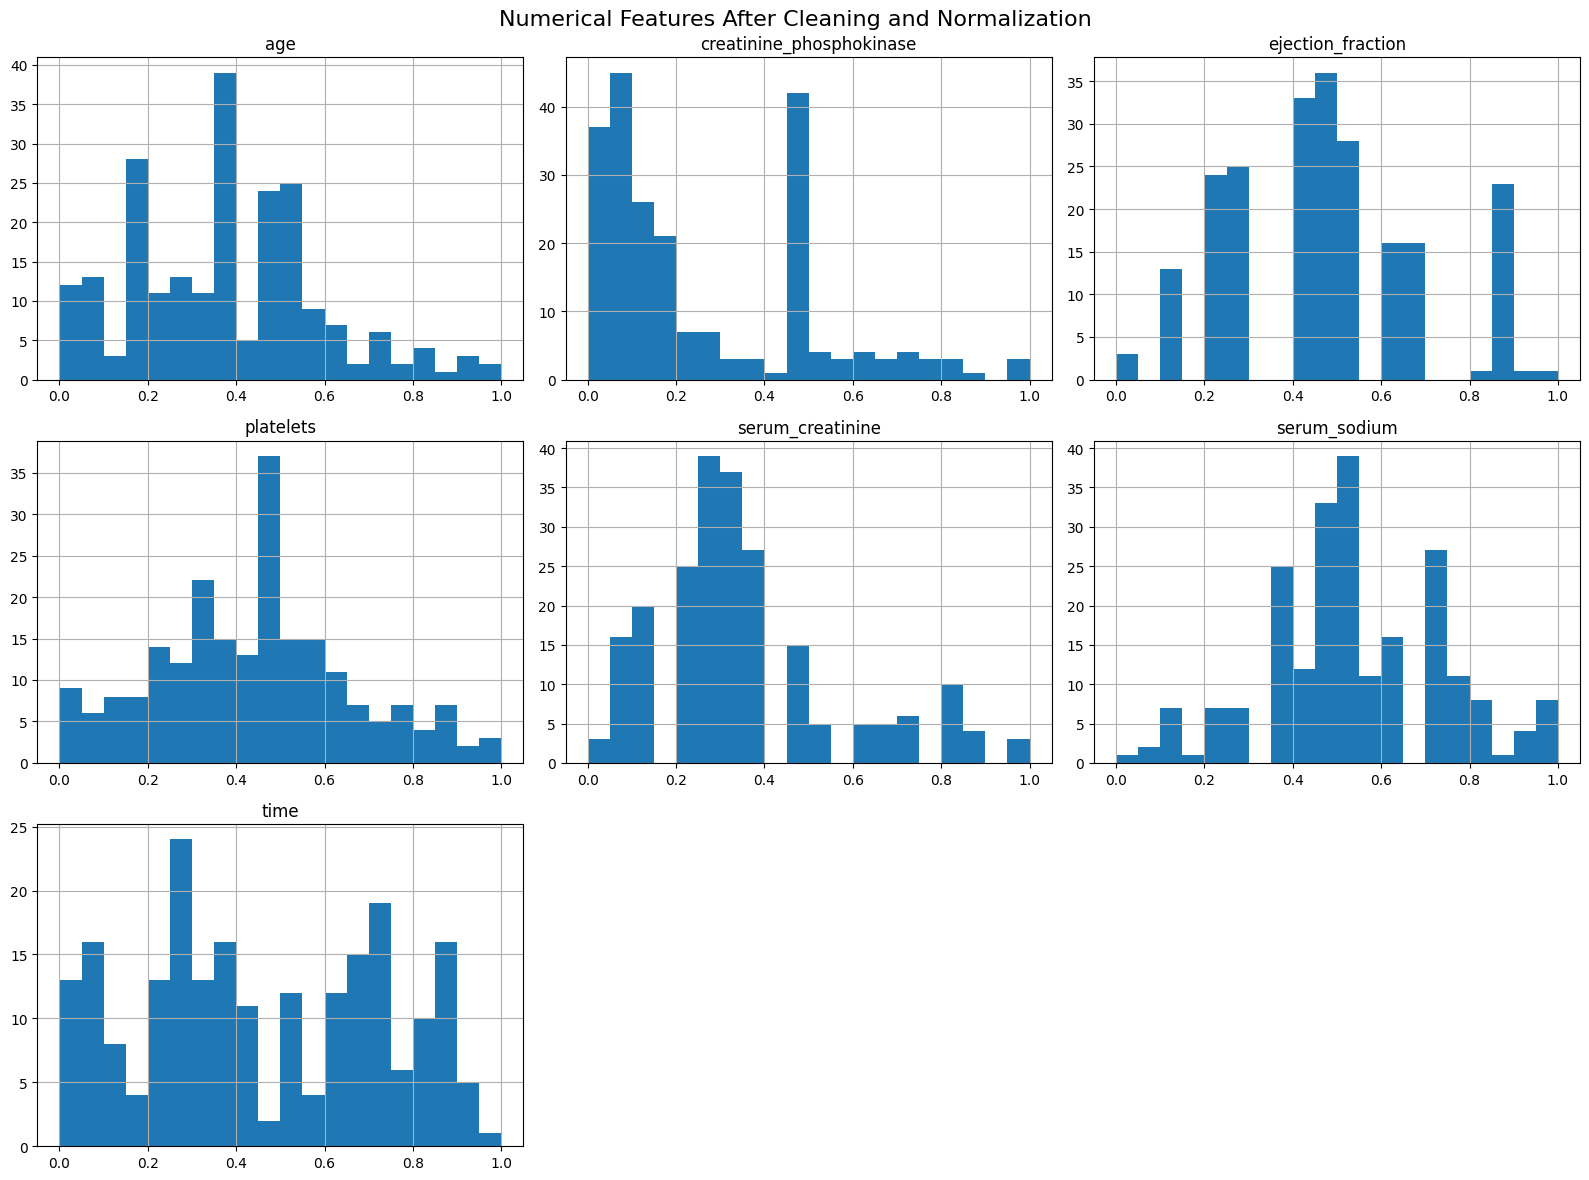

In [37]:
# histograms after cleaning

df[columns_to_scale].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Numerical Features After Cleaning and Normalization",
    fontsize=16
)

plt.tight_layout()
plt.show()

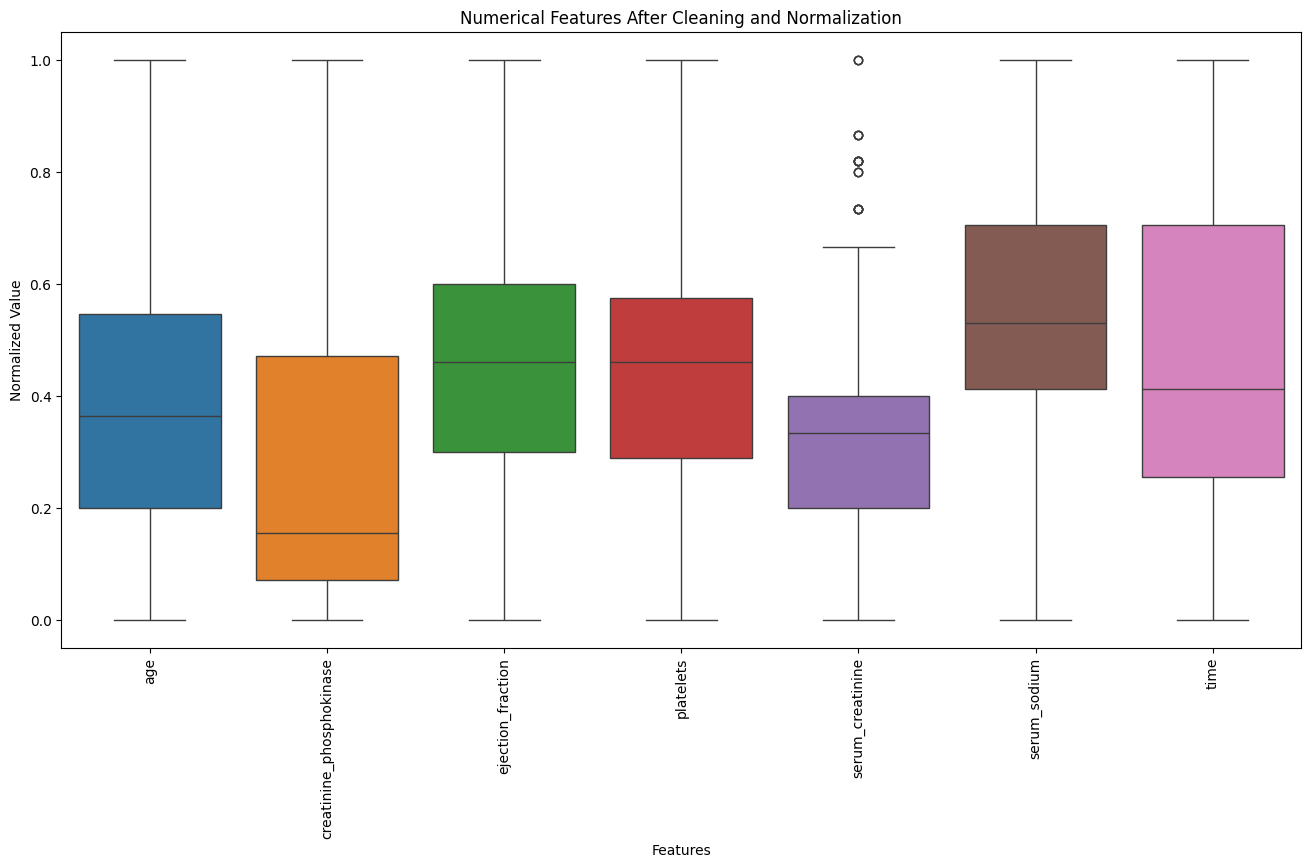

In [38]:
# Boxplots after cleaning

plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df[columns_to_scale]
)

plt.title(
    "Numerical Features After Cleaning and Normalization"
)

plt.xlabel("Features")
plt.ylabel("Normalized Value")

plt.xticks(rotation=90)

plt.show()

In [39]:
# checking missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64


In [40]:
total_missing = df.isnull().sum().sum()

print("\nTotal missing values:", total_missing)


Total missing values: 0


In [42]:
if total_missing == 0:
    print("No missing values remain in the dataset.")
else:
    print("Missing values still remain.")

No missing values remain in the dataset.


In [44]:
# final check

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nMinimum normalized values:")
print(df[columns_to_scale].min().min())

print("\nMaximum normalized values:")
print(df[columns_to_scale].max().max())

print("\nFinal dataset:")
display(df.head())


Number of rows: 220
Number of columns: 16

Total missing values:
0

Minimum normalized values:
0.0

Maximum normalized values:
1.0

Final dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.1,1,0.468852,0.866667,0.117647,1,0.0,0.000000,1,0.269939,False,True
2,0.454545,0,0.098976,0,0.1,0,0.131148,0.466667,0.058824,1,1.0,0.010676,1,0.122699,False,True
3,0.181818,1,0.069113,0,0.1,0,0.288525,0.866667,0.529412,1,0.0,0.010676,1,0.269939,True,False
5,0.909091,1,0.014505,0,0.5,1,0.268852,1.000000,0.235294,1,1.0,0.014235,1,0.834356,False,True
6,0.636364,1,0.184300,0,0.0,0,0.016393,0.400000,0.529412,1,0.0,0.021352,1,0.024540,False,True
